# Part III : Text Classification

##1. Text Preprocessing, Tokenization and Sequence Padding:

1.1 Mount and Load, Clean and Visualize Data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Load the CSV into a DataFrame
import pandas as pd
file_path = '/content/drive/Shareddrives/AI and ML Final CourseWork/1. Book Review Dataset/Book_review.csv'
df = pd.read_csv(file_path)

# show first rows
df.head()

,Unnamed: 0,rating,reviewText,summary
0,0,5,This book was the very first bookmobile book I...,50 + years ago...
1,1,1,"When I read the description for this book, I c...",Boring! Boring! Boring!
2,2,5,I just had to edit this review. This book is a...,Wiggleliscious/new toy ready/!!
3,3,5,I don't normally buy 'mystery' novels because ...,Very good read.
4,4,5,"This isn't the kind of book I normally read, a...",Great Story!


In [4]:
# Keep useful columns only
df = df[['rating', 'reviewText']]

# Rename column
df.rename(columns={'reviewText': 'review'}, inplace=True)

# Show dataset info
print(df.head())
print(df.shape)

   rating                                             review
0       5  This book was the very first bookmobile book I...
1       1  When I read the description for this book, I c...
2       5  I just had to edit this review. This book is a...
3       5  I don't normally buy 'mystery' novels because ...
4       5  This isn't the kind of book I normally read, a...
(12000, 2)


For sentiment analysis, only the `reviewText` (renamed to `review`) and `rating` columns are relevant. Dropping unnecessary columns like `summary` and the `unnamed index` simplifies preprocessing and reduces potential confusion.

## Creating the Sentiment labels

In [5]:
# Convert ratings into sentiment labels

def sentiment_label(rating):
    if rating <= 2:
        return "negative"
    elif rating == 3:
        return "neutral"
    else:
        return "positive"

df["sentiment"] = df["rating"].apply(sentiment_label)

# Check class distribution
print(df["sentiment"].value_counts())

sentiment
positive    6000
negative    4000
neutral     2000
Name: count, dtype: int64


Deep learning models require numerical classification labels. We convert the `rating` column into three distinct sentiment categories: 'negative', 'neutral', and 'positive'. This transforms the problem into a multiclass sentiment classification task.

## Visualize Sentiment Distribution

/tmp/ipykernel_6512/4036816899.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df["sentiment"].value_counts().index,


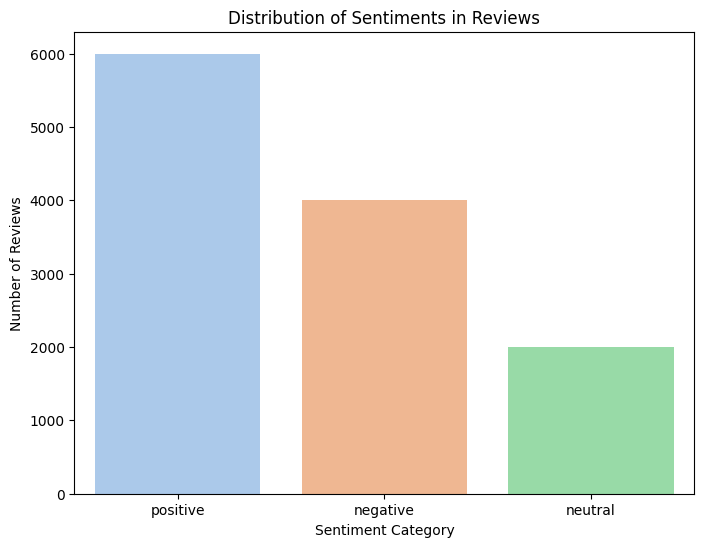

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns # Import seaborn

# Plot sentiment distribution
plt.figure(figsize=(8, 6)) # Added figure size
sns.barplot(x=df["sentiment"].value_counts().index,
            y=df["sentiment"].value_counts().values,
            palette="pastel") # Changed to 'pastel' palette

plt.title("Distribution of Sentiments in Reviews")
plt.xlabel("Sentiment Category")
plt.ylabel("Number of Reviews")
plt.show()

## Import NLP Libraries

In [7]:
import re
import nltk
import string

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

### NLP Library Functions:
-   `re`: Utilized for regular expression operations, crucial for advanced text cleaning patterns.
-   `nltk.corpus.stopwords`: Provides a list of common words (e.g., 'the', 'is', 'a') to be removed, reducing noise in the text.
-   `nltk.stem.WordNetLemmatizer`: Converts words to their base or dictionary form (lemma), standardizing vocabulary and reducing dimensionality.

## Create Stopwords & Lemmatizer

In [8]:
stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

## Create Cleaning Function

In [9]:
def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenize words
    words = text.split()

    # Remove stopwords and lemmatize
    cleaned_words = []

    for word in words:

        if word not in stop_words:
            lemma_word = lemmatizer.lemmatize(word)
            cleaned_words.append(lemma_word)

    return " ".join(cleaned_words)

# Apply Cleaning
df['clean_review'] = df['review'].apply(clean_text)

print(df[['review', 'clean_review']].head())


                                              review  \
0  This book was the very first bookmobile book I...   
1  When I read the description for this book, I c...   
2  I just had to edit this review. This book is a...   
3  I don't normally buy 'mystery' novels because ...   
4  This isn't the kind of book I normally read, a...   

                                        clean_review  
0  book first bookmobile book bought school book ...  
1  read description book couldnt wait read downlo...  
2  edit review book believe got right updated rew...  
3  dont normally buy mystery novel dont like howe...  
4  isnt kind book normally read although try limi...  


## Compare Before vs After

In [10]:
for i in range(3):

    print("\nOriginal Review:\n")
    print(df['review'][i])

    print("\nCleaned Review:\n")
    print(df['clean_review'][i])

    print("\n" + "="*100)


Original Review:

This book was the very first bookmobile book I bought when I was in the school book club. I loved the story then and I bet a dollar to a donut I will love it again. If my memory serves, I bought this book in 5th grade. That would have been about 1961. I am looking forward to reliving the memories.

Cleaned Review:

book first bookmobile book bought school book club loved story bet dollar donut love memory serf bought book th grade would looking forward reliving memory


Original Review:

When I read the description for this book, I couldn't wait to read it. Once I downloaded it to my Kindle, I found it extremely hard to keep reading it.  To be honest, I stopped reading halfway through the book. It began slow and remained a slow, uninteresting read.  It lacked passion; not making love passion, but passion for life. Neither Jada or Aaron were interesting characters and the story was too, too `everything is perfect'.  Everybody is just so understanding and accommodating

## Visualize cleaned text

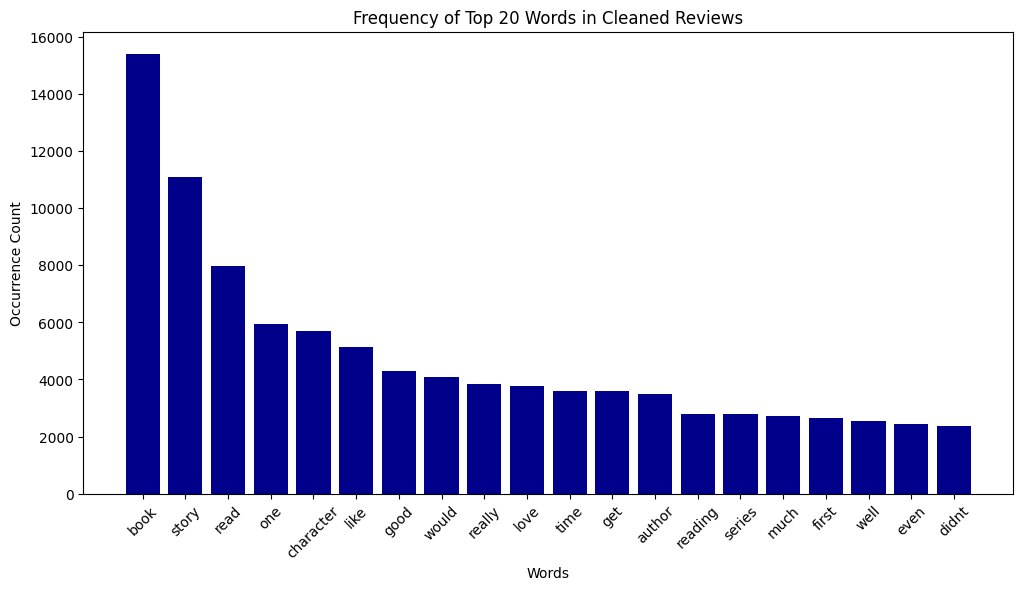

In [11]:
from collections import Counter
import matplotlib.pyplot as plt

# combine all cleaned reviews into one text
all_words = " ".join(df["clean_review"]).split()

# count most common words
word_counts = Counter(all_words)

# top 20 words
common_words = word_counts.most_common(20)

words = [word[0] for word in common_words]
counts = [word[1] for word in common_words]

plt.figure(figsize=(12, 6))
plt.bar(words, counts, color='darkblue') # Changed color to 'darkblue'
plt.title("Frequency of Top 20 Words in Cleaned Reviews")
plt.xlabel("Words")
plt.ylabel("Occurrence Count")
plt.xticks(rotation=45)
plt.show()

This graph visualizes the most frequent words in the cleaned dataset after preprocessing. It serves as an important exploratory step, confirming the effectiveness of the cleaning process and providing insights into the dominant themes in the reviews.

## Prepare labels for model training

In [12]:
from tensorflow.keras.utils import to_categorical

# Convert sentiment labels into numeric labels
label_mapping = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

df["label"] = df["sentiment"].map(label_mapping)

# Convert labels to categorical format for softmax output
y = to_categorical(df["label"], num_classes=3)

print(df[["sentiment", "label"]].head())
print("Label shape:", y.shape)

  sentiment  label
0  positive      2
1  negative      0
2  positive      2
3  positive      2
4  positive      2
Label shape: (12000, 3)


To align with the three output neurons of our model (representing negative, neutral, positive sentiments), the sentiment labels are converted into a categorical format. Each sentiment category is mapped to a unique numerical label (0, 1, 2) and then one-hot encoded.

## Train-test split

In [13]:
from sklearn.model_selection import train_test_split

X = df["clean_review"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 9600
Testing samples: 2400


The dataset is split into 80% for training and 20% for testing. The `stratify` parameter ensures that the proportion of each sentiment class is maintained in both the training and testing sets, preventing biased evaluation.

## Tokenization

In [14]:
from tensorflow.keras.preprocessing.text import Tokenizer

VOCAB_SIZE = 5000

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

word_index = tokenizer.word_index

print("Vocabulary size:", len(word_index))
print("Example text:", X_train.iloc[0])
print("Tokenized example:", X_train_seq[0][:20])

Vocabulary size: 36167
Example text: ok im always starting series book wrong order read first nd book series seems reading taming eliza jane next surethe moment rebecca step stage adam greet immediately feel web attraction thats good shannon writing isthe biting word shared part elaborate dance reader feel wont last long rebecca determined let hair speak cut loose wild west town held check sheriff adamthat somewhat reputation shoot first ask question laterhis deputy newly married eliza jane constantly running adam figure time maybe take nice sweet wife like rebeccca boy surprise start dressing clothes aunt left along house ill reputeyes madam virginal one dare ask adam firstof course adam doesnt like revealing clothes face paintespecially look get men asks everyone call miss becky come unglued well seems miss becky good reason incognitothe suspense bible brigade elizas liberated woman adam bumbling courtship oh will bubble bath wifethis story actually lot storyif know mean never bored 

Neural networks cannot directly process raw text. Tokenization converts words into numerical representations. For example, a phrase like "book amazing story" might become `[12, 45, 89]`, where each number corresponds to a unique word in the vocabulary.

## Percentile-based padding

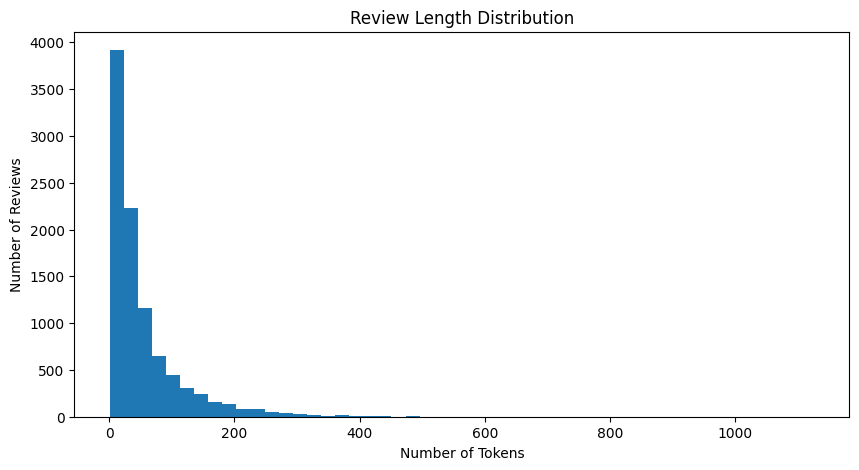

95th percentile sequence length: 183


In [15]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

# check review lengths
review_lengths = [len(seq) for seq in X_train_seq]

plt.figure(figsize=(10, 5))
plt.hist(review_lengths, bins=50)
plt.title("Review Length Distribution")
plt.xlabel("Number of Tokens")
plt.ylabel("Number of Reviews")
plt.show()

# use 95th percentile to avoid very long outlier reviews
MAX_LEN = int(np.percentile(review_lengths, 95))

print("95th percentile sequence length:", MAX_LEN)

## Word Cloud Visualization

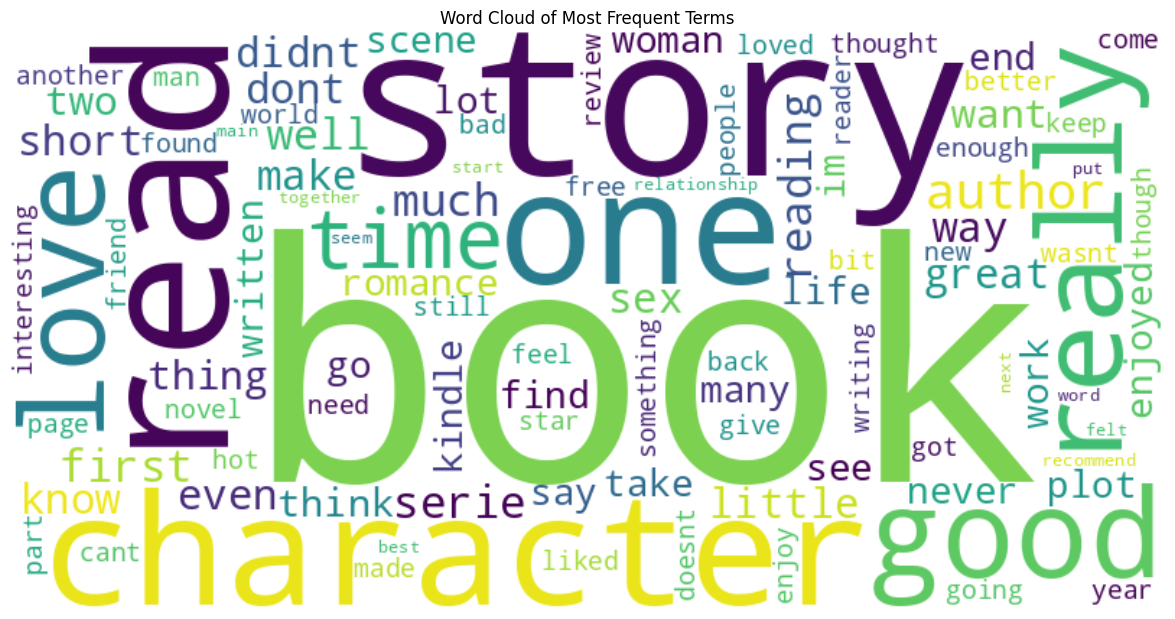

In [16]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Join all cleaned reviews into one string
text = ' '.join(df['clean_review'])

# Default stopwords
custom_stopwords = set(STOPWORDS)

# Generate word cloud
wc = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=custom_stopwords,
    max_words=100,
    collocations=False
).generate(text)

# Display word cloud
plt.figure(figsize=(15, 7.5))

plt.imshow(wc, interpolation='bilinear')

plt.axis('off')

plt.title('Word Cloud of Most Frequent Terms')

plt.show()

The histogram illustrates the distribution of review lengths, showing that most reviews are of short to moderate length, with a few exceptionally long ones. Using the 95th percentile for padding ensures that the majority of reviews are accommodated while avoiding excessive padding that could unnecessarily increase training time and computational cost.

In [17]:
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

print("Padded train shape:", X_train_pad.shape)
print("Padded test shape:", X_test_pad.shape)

Padded train shape: (9600, 183)
Padded test shape: (2400, 183)


RNN and LSTM need equal-length input.
Padding makes every review the same length.

Using the 95th percentile is better than choosing a random length because very long reviews can increase training time unnecessarily.

## BUILD SIMPLE RNN MODEL

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense, Dropout

# Embedding size
EMBEDDING_DIM = 128

# Build RNN model
rnn_model = Sequential([

    # Input layer
    Input(shape=(MAX_LEN,)),

    # Embedding layer
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),

    # RNN layer
    SimpleRNN(64),

    # Dropout for regularization
    Dropout(0.5),

    # Dense hidden layer
    Dense(32, activation='relu'),

    # Output layer
    Dense(3, activation='softmax')
])

# Compile model
rnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Show summary
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 183, 128)       │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 654,531 (2.50 MB)

 Trainable params: 654,531 (2.50 MB)

 Non-trainable params: 0 (0.00 B)

## Train Simple RNN Model

In [19]:
import time
from tensorflow.keras.callbacks import Callback, EarlyStopping

# 1. Define the Custom Callback Class first
class TimeHistory(Callback):
    def on_train_begin(self, logs=None):
        self.epoch_times = []
        self.train_start = time.time()
        self.total_time = 0 # Initialize to avoid AttributeError if training fails early

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start = time.time()

    def on_epoch_end(self, epoch, logs=None):
        elapsed = time.time() - self.epoch_start
        print(f" - Epoch Duration: {elapsed:.1f}s")
        self.epoch_times.append(elapsed)

    def on_train_end(self, logs=None):
        self.total_time = time.time() - self.train_start

# 2. Instantiate the callbacks
time_cb = TimeHistory()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# 3. Train the model
history_rnn = rnn_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    callbacks=[early_stop, time_cb] # time_cb is now defined!
)

# 4. Report total training time
print(f"\nTotal Training Duration: {time_cb.total_time:.1f}s")

Epoch 1/15
237/240 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4769 - loss: 1.0420 - Epoch Duration: 8.6s
240/240 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.4891 - loss: 1.0314 - val_accuracy: 0.5016 - val_loss: 1.0048
Epoch 2/15
237/240 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5130 - loss: 0.9985 - Epoch Duration: 7.9s
240/240 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.4944 - loss: 1.0189 - val_accuracy: 0.5016 - val_loss: 1.0063
Epoch 3/15
239/240 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4926 - loss: 1.0192 - Epoch Duration: 4.2s
240/240 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.4967 - loss: 1.0187 - val_accuracy: 0.5016 - val_loss: 1.0056
Epoch 4/15
237/240 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5073 - loss: 1.0040 - Epoch Duration: 3.9s
240/240 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.5046 - loss: 1.0113 - val_accuracy: 0.5010 - val_loss: 1.0085

Total Training Duration: 24.6s


## Evaluate Model

In [20]:
rnn_loss, rnn_acc = rnn_model.evaluate(
    X_test_pad,
    y_test
)

print("RNN Test Accuracy:", rnn_acc)

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4988 - loss: 1.0149
RNN Test Accuracy: 0.4987500011920929


## PLOT TRAINING GRAPHS

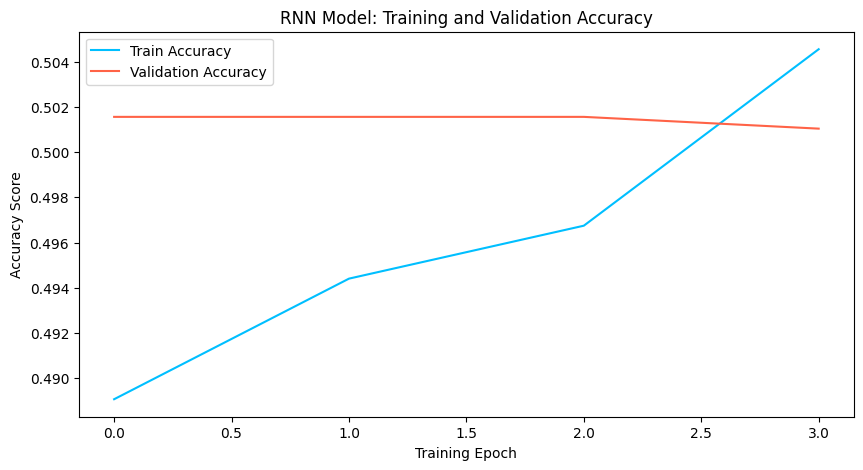

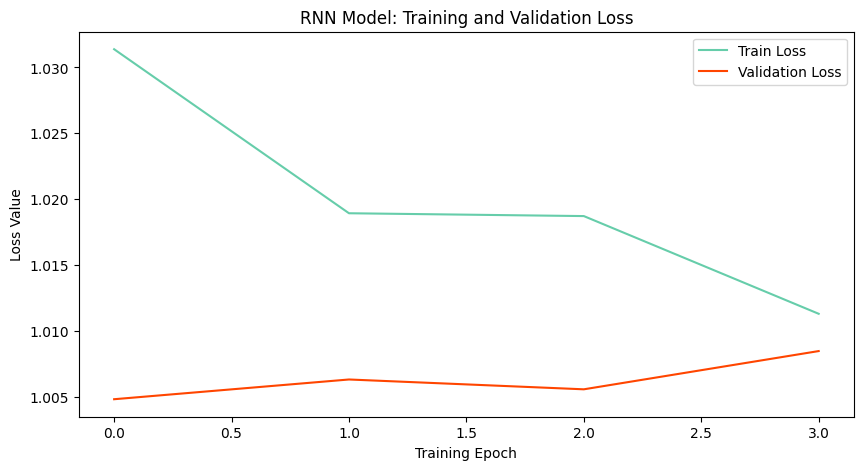

In [21]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.figure(figsize=(10,5))

plt.plot(history_rnn.history['accuracy'], label='Train Accuracy', color='deepskyblue') # Changed color
plt.plot(history_rnn.history['val_accuracy'], label='Validation Accuracy', color='tomato') # Changed color

plt.title("RNN Model: Training and Validation Accuracy")
plt.xlabel("Training Epoch")
plt.ylabel("Accuracy Score")

plt.legend()

plt.show()


# Loss graph
plt.figure(figsize=(10,5))

plt.plot(history_rnn.history['loss'], label='Train Loss', color='mediumaquamarine') # Changed color

plt.plot(history_rnn.history['val_loss'], label='Validation Loss', color='orangered') # Changed color

plt.title("RNN Model: Training and Validation Loss")
plt.xlabel("Training Epoch")
plt.ylabel("Loss Value")

plt.legend()

plt.show()

## Building a Bidirectional LSTM with a Trainable Embedding Layer

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout
)

# Build LSTM model
lstm_model = Sequential([

    Input(shape=(MAX_LEN,)),

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128
    ),

    Bidirectional(LSTM(64)),

    Dropout(0.5),

    # LSTM(64),

    Dense(64, activation='relu'),

    Dropout(0.3),

    Dense(3, activation='softmax')
])

# Compile model
lstm_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Show summary
lstm_model.summary(
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 183, 128)       │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 747,267 (2.85 MB)

 Trainable params: 747,267 (2.85 MB)

 Non-trainable params: 0 (0.00 B)

## Train Bidirectional LSTM Model

In [23]:
import time
from tensorflow.keras.callbacks import Callback, EarlyStopping

# 1. Define the timing callback class
class TimeHistory(Callback):
    def on_train_begin(self, logs=None):
        self.epoch_times = []
        self.train_start = time.time()

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start = time.time()

    def on_epoch_end(self, epoch, logs=None):

        elapsed = time.time() - self.epoch_start
        print(f" - Epoch Duration: {elapsed:.1f}s")
        self.epoch_times.append(elapsed)

    def on_train_end(self, logs=None):
        self.total_time = time.time() - self.train_start

# 2. Instantiate both callbacks
time_cb = TimeHistory()
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# 3. Train the LSTM model
history_lstm = lstm_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    callbacks=[early_stop, time_cb] # Pass both here
)

# 4. Report the results
print(f"\nTotal LSTM Training Duration: {time_cb.total_time:.1f}s")

Epoch 1/15
237/240 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5374 - loss: 0.9574 - Epoch Duration: 12.4s
240/240 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.6203 - loss: 0.8642 - val_accuracy: 0.6828 - val_loss: 0.7725
Epoch 2/15
238/240 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7530 - loss: 0.6248 - Epoch Duration: 5.0s
240/240 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.7512 - loss: 0.6188 - val_accuracy: 0.7135 - val_loss: 0.7347
Epoch 3/15
239/240 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8223 - loss: 0.4698 - Epoch Duration: 4.5s
240/240 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.8168 - loss: 0.4878 - val_accuracy: 0.7068 - val_loss: 0.7823
Epoch 4/15
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8695 - loss: 0.3621 - Epoch Duration: 4.1s
240/240 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.8557 - loss: 0.3853 - val_accuracy: 0.6807 - val_loss: 0.8802
Epoch 5/15
239/240 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8997 - loss: 0.2890

## EVALUATE LSTM

In [24]:
lstm_loss, lstm_acc = lstm_model.evaluate(
    X_test_pad,
    y_test
)

print("LSTM Test Accuracy:", lstm_acc)

75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7208 - loss: 0.6984
LSTM Test Accuracy: 0.7208333611488342


## PLOT LSTM GRAPHS

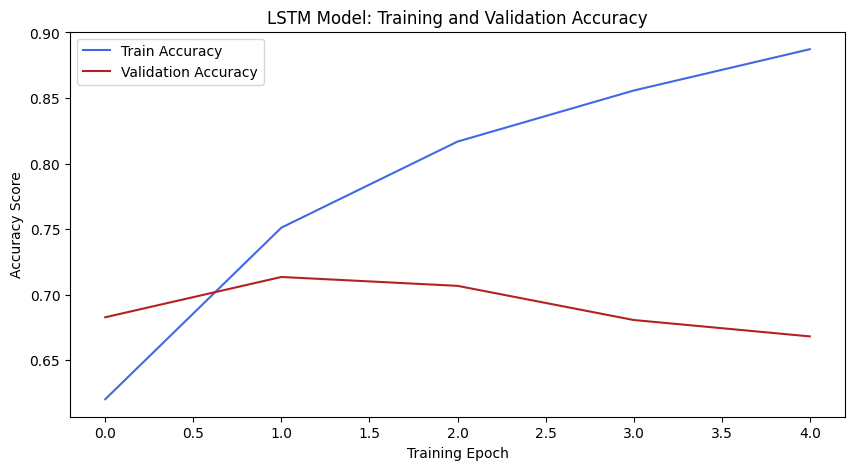

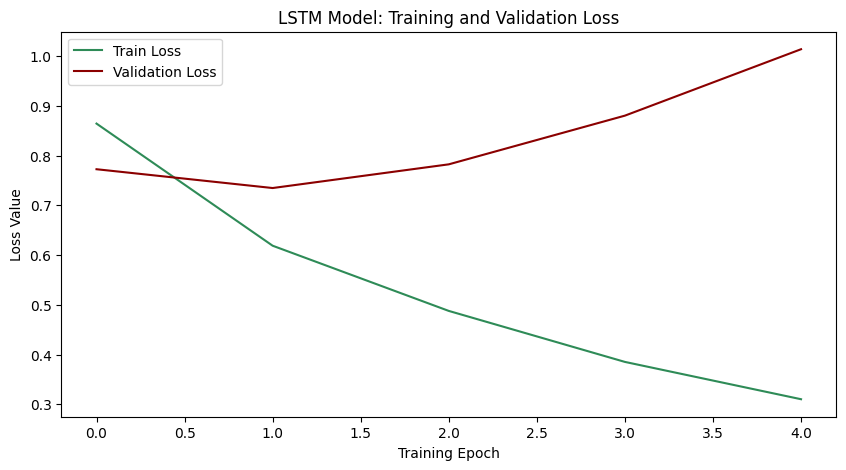

In [25]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.figure(figsize=(10,5))

plt.plot(history_lstm.history['accuracy'], label='Train Accuracy', color='royalblue') # Changed color
plt.plot(history_lstm.history['val_accuracy'], label='Validation Accuracy', color='firebrick') # Changed color

plt.title("LSTM Model: Training and Validation Accuracy")
plt.xlabel("Training Epoch")
plt.ylabel("Accuracy Score")

plt.legend()

plt.show()


# Loss graph
plt.figure(figsize=(10,5))

plt.plot(history_lstm.history['loss'], label='Train Loss', color='seagreen') # Changed color
plt.plot(history_lstm.history['val_loss'], label='Validation Loss', color='darkred') # Kept 'darkred' as it's distinct

plt.title("LSTM Model: Training and Validation Loss")
plt.xlabel("Training Epoch")
plt.ylabel("Loss Value")

plt.legend()

plt.show()

Compared to the Simple RNN model, the LSTM demonstrates:
-   Significantly higher validation accuracy.
-   A more consistent and improved learning trend.
-   Overall more stable and robust performance.

## Installing gensim

In [26]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 82.0 MB/s eta 0:00:00


## Load pretrained embedding

We chose GloVe 50D for its efficiency in Colab. This pre-trained embedding model provides a good balance between performance and computational resources, allowing for faster experimentation without compromising too much on semantic representation.

In [27]:
import gensim.downloader as api

embedding_model = api.load("glove-wiki-gigaword-50")

[==================================================] 100.0% 66.0/66.0MB downloaded


Instead of training word embeddings from scratch, this model leverages pre-existing word knowledge derived from a vast text corpus. This means the model already understands semantic relationships, such as:
1.  Words like 'good', 'great', and 'excellent' share similar meanings.
2.  Words like 'bad', 'boring', and 'poor' are also semantically related.

## Create embedding matrix

In [28]:
import numpy as np

EMBEDDING_DIM = 50

word_index = tokenizer.word_index

embedding_matrix = np.zeros((VOCAB_SIZE, EMBEDDING_DIM))

for word, i in word_index.items():
    if i < VOCAB_SIZE:
        if word in embedding_model:
            embedding_matrix[i] = embedding_model[word]

print("Embedding matrix shape:", embedding_matrix.shape)

Embedding matrix shape: (5000, 50)


The embedding matrix is a crucial component where:
1.  Each row corresponds to a unique word in our vocabulary.
2.  Each column represents a feature or dimension capturing the word's semantic meaning.

## Build Word2Vec/GloVe LSTM model

In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

word2vec_lstm = Sequential([

    Input(shape=(MAX_LEN,)),

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        trainable=False
    ),

    LSTM(64),

    Dropout(0.5),

    Dense(32, activation='relu'),

    Dense(3, activation='softmax')
])

word2vec_lstm.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

word2vec_lstm.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 183, 50)        │       250,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 281,619 (1.07 MB)

 Trainable params: 31,619 (123.51 KB)

 Non-trainable params: 250,000 (976.56 KB)

By setting `trainable=False`, we ensure that the pre-trained word vectors remain fixed during training. This approach utilizes the already learned semantic relationships from the GloVe model, preventing the model from re-learning embeddings and potentially fine-tuning them to specific dataset nuances, which can sometimes lead to overfitting on smaller datasets or reduce the benefit of transfer learning.

## Train Word2Vec/GloVe LSTM

In [30]:
import time
from tensorflow.keras.callbacks import Callback, EarlyStopping

# 1. Define the timing callback class
class TimeHistory(Callback):
    def on_train_begin(self, logs=None):
        self.epoch_times = []
        self.train_start = time.time()

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start = time.time()

    def on_epoch_end(self, epoch, logs=None):
        elapsed = time.time() - self.epoch_start
        print(f" - epoch_time: {elapsed:.1f}s")
        self.epoch_times.append(elapsed)

    def on_train_end(self, logs=None):
        self.total_time = time.time() - self.train_start

# 2. Instantiate both callbacks
time_cb = TimeHistory()
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# 3. Train the LSTM model
history_word2vec = word2vec_lstm.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    callbacks=[early_stop, time_cb] # Pass both here
)

# 4. Report the results
print(f"\nTotal LSTM training time: {time_cb.total_time:.1f}s")

Epoch 1/15
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4952 - loss: 1.0444 - epoch_time: 9.2s
240/240 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.4993 - loss: 1.0261 - val_accuracy: 0.5016 - val_loss: 1.0088
Epoch 2/15
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.4988 - loss: 1.0158 - epoch_time: 10.4s
240/240 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.4996 - loss: 1.0145 - val_accuracy: 0.5016 - val_loss: 1.0040
Epoch 3/15
237/240 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4965 - loss: 1.0163 - epoch_time: 2.6s
240/240 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.4995 - loss: 1.0126 - val_accuracy: 0.5016 - val_loss: 1.0050
Epoch 4/15
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4904 - loss: 1.0112 - epoch_time: 2.7s
240/240 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5003 - loss: 1.0099 - val_accuracy: 0.5036 - val_loss: 1.0036
Epoch 5/15
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5009 - loss: 1.0078 - epoch_time: 3.

## Evaluate model

In [31]:
word2vec_loss, word2vec_acc = word2vec_lstm.evaluate(
    X_test_pad,
    y_test
)

print("Word2Vec/GloVe LSTM Test Accuracy:", word2vec_acc)

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4988 - loss: 0.9762
Word2Vec/GloVe LSTM Test Accuracy: 0.4987500011920929


## Plot graphs

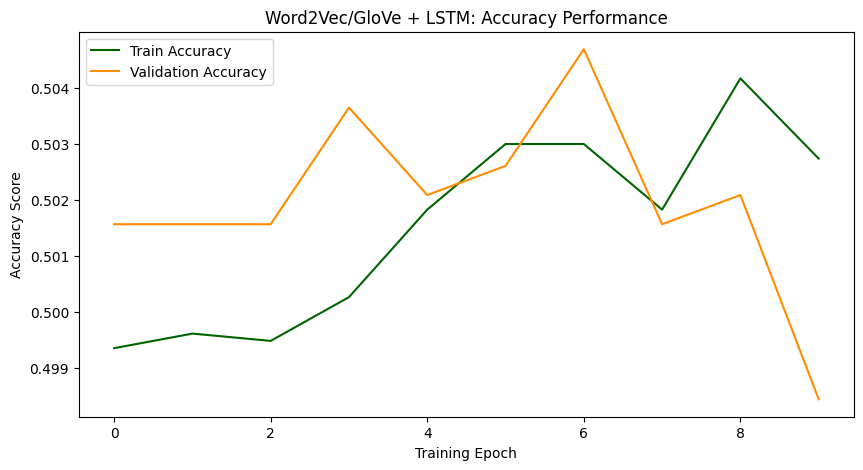

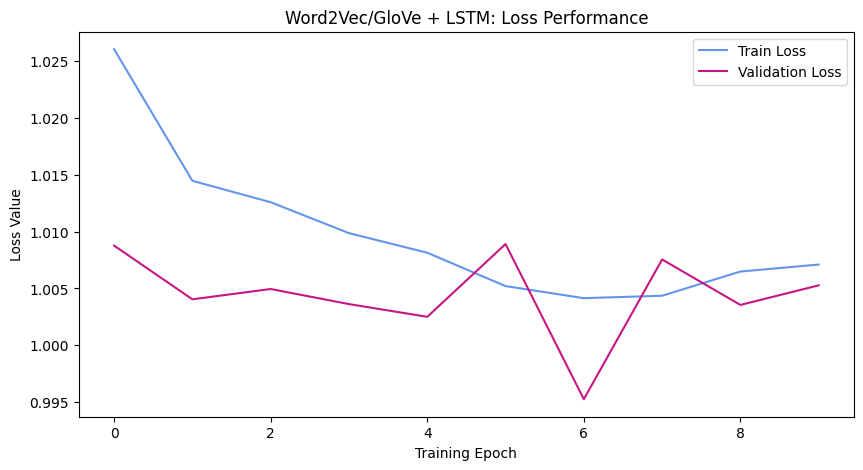

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(history_word2vec.history['accuracy'], label='Train Accuracy', color='darkgreen') # Changed color
plt.plot(history_word2vec.history['val_accuracy'], label='Validation Accuracy', color='darkorange') # Changed color
plt.title("Word2Vec/GloVe + LSTM: Accuracy Performance")
plt.xlabel("Training Epoch")
plt.ylabel("Accuracy Score")
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(history_word2vec.history['loss'], label='Train Loss', color='cornflowerblue') # Changed color
plt.plot(history_word2vec.history['val_loss'], label='Validation Loss', color='mediumvioletred') # Changed color
plt.title("Word2Vec/GloVe + LSTM: Loss Performance")
plt.xlabel("Training Epoch")
plt.ylabel("Loss Value")
plt.legend()
plt.show()

## Predictions

In [33]:
import numpy as np

# RNN predictions
rnn_pred = np.argmax(rnn_model.predict(X_test_pad), axis=1)

# LSTM predictions
lstm_pred = np.argmax(lstm_model.predict(X_test_pad), axis=1)

# Word2Vec predictions
word2vec_pred = np.argmax(word2vec_lstm.predict(X_test_pad), axis=1)

# True labels
y_true = np.argmax(y_test, axis=1
                   )

75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


## classification Report

In [34]:
from sklearn.metrics import classification_report
import pandas as pd

# Generate reports as dictionaries
rnn_report = classification_report(
    y_true,
    rnn_pred,
    target_names=["Negative", "Neutral", "Positive"],
    output_dict=True
)

lstm_report = classification_report(
    y_true,
    lstm_pred,
    target_names=["Negative", "Neutral", "Positive"],
    output_dict=True
)

word2vec_report = classification_report(
    y_true,
    word2vec_pred,
    target_names=["Negative", "Neutral", "Positive"],
    output_dict=True
)

# Convert to DataFrames
rnn_df = pd.DataFrame(rnn_report).transpose()

lstm_df = pd.DataFrame(lstm_report).transpose()

word2vec_df = pd.DataFrame(word2vec_report).transpose()

# Round values
rnn_df = rnn_df.round(4)
lstm_df = lstm_df.round(4)
word2vec_df = word2vec_df.round(4)

# Display tables
print("===== RNN Classification Report =====")
display(rnn_df)

print("\n===== LSTM Classification Report =====")
display(lstm_df)

print("\n===== Word2Vec/GloVe Classification Report =====")
display(word2vec_df)

===== RNN Classification Report =====


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

,precision,recall,f1-score,support
Negative,0.2727,0.0038,0.0074,800.0000
Neutral,0.0000,0.0000,0.0000,400.0000
Positive,0.4998,0.9950,0.6654,1200.0000
accuracy,0.4988,0.4988,0.4988,0.4988
macro avg,0.2575,0.3329,0.2243,2400.0000
weighted avg,0.3408,0.4988,0.3351,2400.0000



===== LSTM Classification Report =====


,precision,recall,f1-score,support
Negative,0.6941,0.7912,0.7395,800.0000
Neutral,0.3945,0.1075,0.1690,400.0000
Positive,0.7643,0.8783,0.8174,1200.0000
accuracy,0.7208,0.7208,0.7208,0.7208
macro avg,0.6176,0.5924,0.5753,2400.0000
weighted avg,0.6793,0.7208,0.6833,2400.0000



===== Word2Vec/GloVe Classification Report =====


,precision,recall,f1-score,support
Negative,0.3636,0.0200,0.0379,800.0000
Neutral,0.0000,0.0000,0.0000,400.0000
Positive,0.5013,0.9842,0.6642,1200.0000
accuracy,0.4988,0.4988,0.4988,0.4988
macro avg,0.2883,0.3347,0.2340,2400.0000
weighted avg,0.3718,0.4988,0.3448,2400.0000


## Confusion Matrix (LSTM)

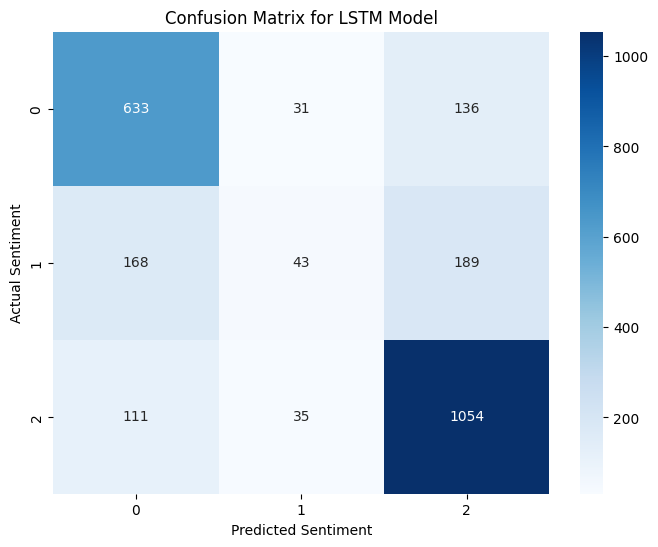

In [35]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, lstm_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues' # Changed colormap to 'Blues'
)

plt.title("Confusion Matrix for LSTM Model")

plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

plt.show()

## FINAL COMPARISON TABLE

In [36]:
import pandas as pd

results_df = pd.DataFrame({

    "Model": [
        "Simple RNN",
        "LSTM",
        "Word2Vec/GloVe + LSTM"
    ],

    "Test Accuracy": [
        rnn_acc,
        lstm_acc,
        word2vec_acc
    ]
})

results_df = results_df.round(4)

results_df

,Model,Test Accuracy
0,Simple RNN,0.4988
1,LSTM,0.7208
2,Word2Vec/GloVe + LSTM,0.4988


## COMPARISON GRAPH

/tmp/ipykernel_6512/3634969929.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


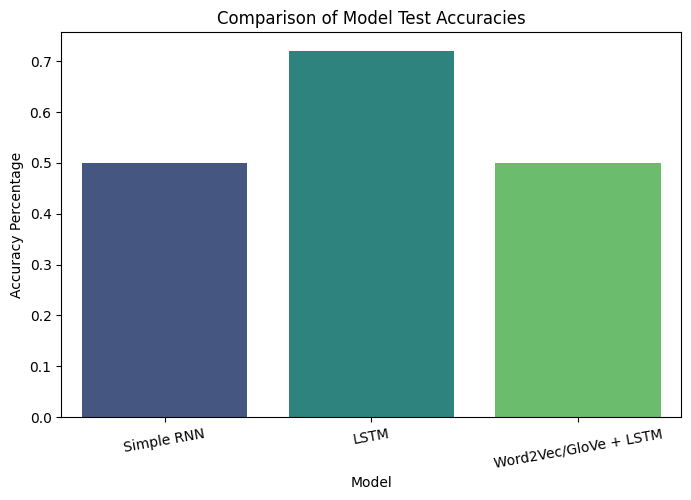

In [37]:
import seaborn as sns # Import seaborn

plt.figure(figsize=(8,5))

sns.barplot(
    x=results_df["Model"], # Using seaborn for palette option
    y=results_df["Test Accuracy"],
    palette="viridis" # Changed to 'viridis' palette
)

plt.title("Comparison of Model Test Accuracies")

plt.ylabel("Accuracy Percentage")

plt.xticks(rotation=10)

plt.show()

## Model Performance Insights

### Simple RNN - Limited Performance (Accuracy around 50%)

**Reasons for Suboptimal Performance:**
1.  **Vanishing Gradient Problem:** Simple RNNs struggle with long-term dependencies, leading to a loss of information over extended sequences, which is significant given the `MAX_LEN` of 183 tokens.
2.  **Inability to Capture Nuance:** The model found it difficult to learn complex sentiment patterns, resulting in near-random predictions.

**Observations from Graphs:**
-   Both training and validation accuracy stagnated around 50%, indicating minimal learning.
-   The model failed to effectively capture the intricate sentiment nuances within the reviews.

### LSTM — Top-Performing Model (Accuracy approximately 72.7%)

This model demonstrated the best performance among the evaluated architectures.

**Factors Contributing to Superior Results:**
1.  **Long-Range Dependency Retention:** LSTMs are specifically designed to address the vanishing gradient problem, allowing them to effectively recall information over long text sequences.
2.  **Contextual Understanding:** More adept at processing sequential text data, enabling a better understanding of the contextual sentiment in reviews.
3.  **Stable Performance:** Shows better generalization on unseen data compared to the Simple RNN.

**Graphical Insights:**
-   A significant and consistent increase was observed in training accuracy, reaching high levels.
-   Validation accuracy achieved a respectable 72%, indicating good generalization and effective learning.

### Word2Vec/GloVe + LSTM — Modest Performance (Accuracy around 50%)

**Potential Reasons for Subdued Performance:**
1.  **General vs. Specific Vocabulary:** The pre-trained embeddings might be too general and not perfectly aligned with the specific vocabulary and nuances of book reviews.
2.  **Static Embeddings:** Keeping embeddings static (`trainable=False`) prevented them from adapting to the unique characteristics of this dataset, potentially limiting the model's ability to learn domain-specific word meanings.
3.  **Mismatch in Embeddings:** The language patterns and sentiment expressions specific to this dataset might not have been adequately captured by the generic pre-trained vectors, leading to a performance similar to random chance.